CO3 - AT2
COMPARATIVE ANALYSIS OF ACTOR-CRITIC METHODS
A2C AND A3C

Environment: CartPole-v1
State Size: 4
Action Size: 2
Discount Factor: 0.99
Learning Rate: 0.001
Training Episodes: 300

Training A2C...
A2C Training Completed.
A2C Training Time: 53.393 seconds

Training A3C...
A3C Training Completed.
A3C Training Time: 50.188 seconds


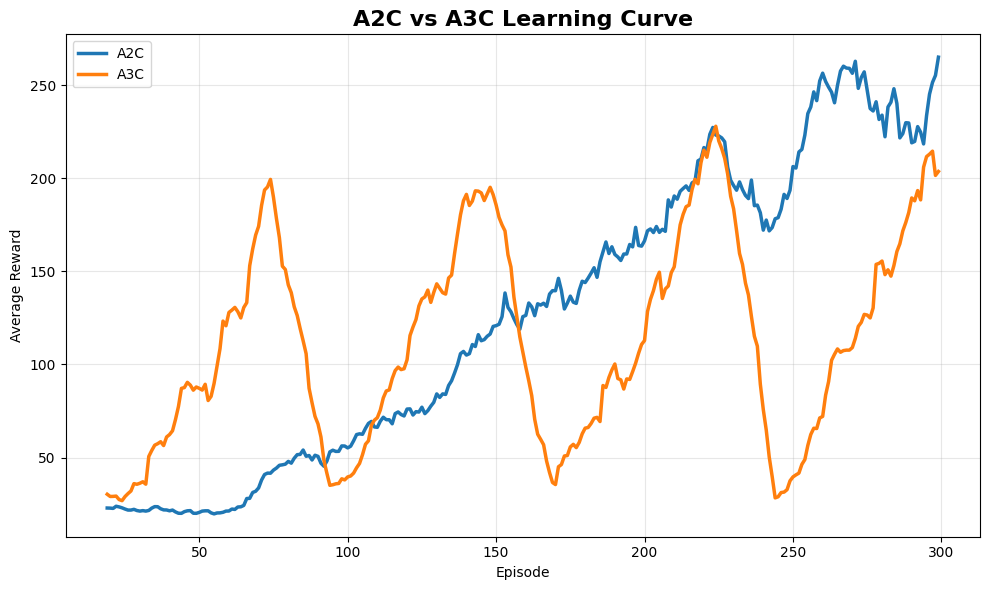

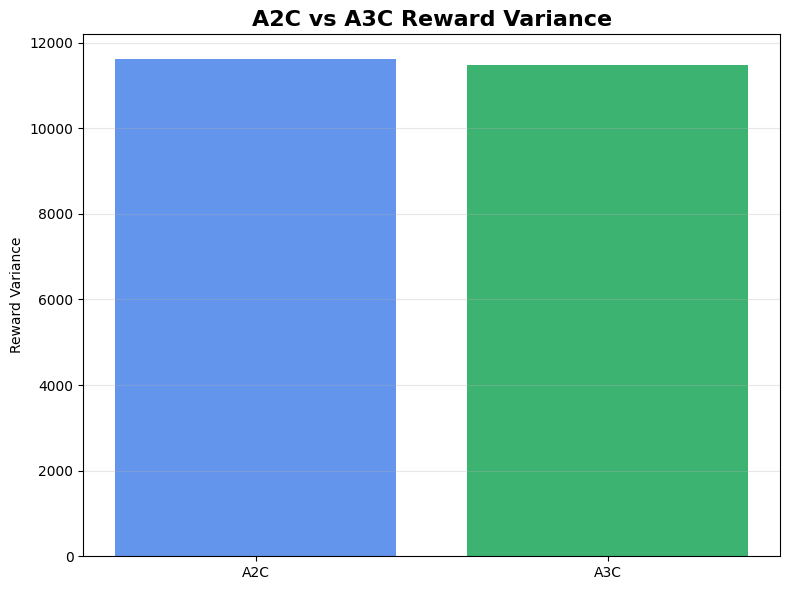

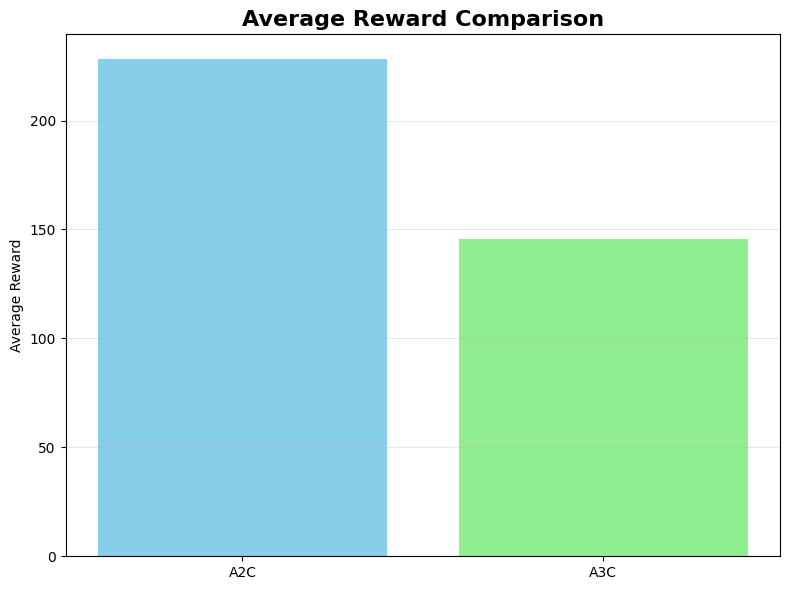

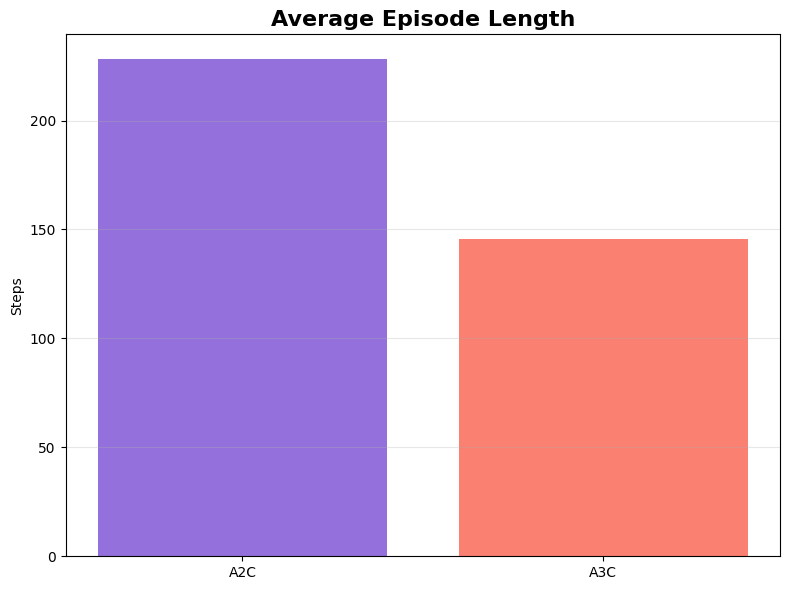

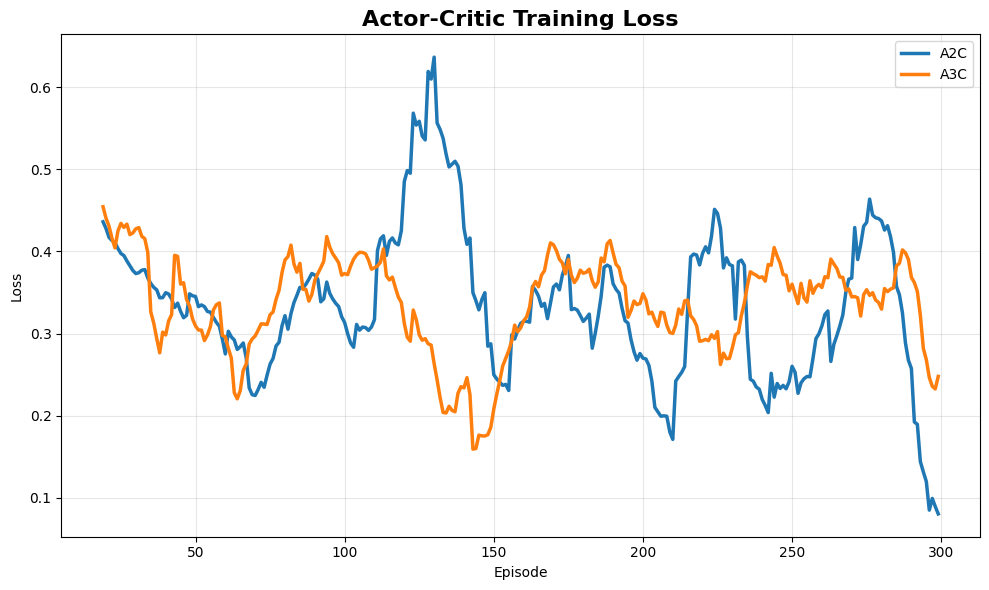



PERFORMANCE COMPARISON


,Metric,A2C,A3C
0,Algorithm Type,Synchronous Actor-Critic,Multi-Worker Actor-Critic
1,Training Episodes,300,300
2,Average Reward,228.14,145.39
3,Maximum Reward,500.0,500.0
4,Reward Variance,11614.16,11486.06
5,Stability,0.0092,0.0092
6,Success Rate,54.0,29.0
7,Average Steps,228.14,145.39
8,Training Time,53.393,50.188




SUMMARY TABLE


,Algorithm,Variance,Stability,Average Reward,Maximum Reward,Success Rate (%),Average Steps,Training Time
0,A2C,11614.160,0.0092,228.14,500.0,54.0,228.14,53.393
1,A3C,11486.058,0.0092,145.39,500.0,29.0,145.39,50.188




FINAL RESULT
Higher Final Average Reward: A2C
Lower Reward Variance: A3C
More Stable: A3C


CONCLUSION
A2C and A3C were implemented using the CartPole-v1 environment.
A2C uses synchronous Actor-Critic learning, while A3C uses
multiple workers that interact with separate environments
and update a shared Actor-Critic model.
The algorithms were compared using reward, variance,
stability, success rate, episode length, loss, and training time.
The comparison demonstrates the differences between
synchronous and multi-worker Actor-Critic learning.

Generated Files:
1. A2C_A3C_Performance.csv
2. A2C_A3C_Summary.csv
3. A2C_A3C_Episode_Results.csv

CO3 - AT2 Completed Successfully.


In [1]:
!pip -q install gymnasium

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import time
import threading

np.random.seed(42)
torch.manual_seed(42)

print("=" * 80)
print("CO3 - AT2")
print("COMPARATIVE ANALYSIS OF ACTOR-CRITIC METHODS")
print("A2C AND A3C")
print("=" * 80)

env = gym.make("CartPole-v1")

state_size = env.observation_space.shape[0]
action_size = env.action_space.n

gamma = 0.99
learning_rate = 0.001
episodes = 300

print("\nEnvironment: CartPole-v1")
print("State Size:", state_size)
print("Action Size:", action_size)
print("Discount Factor:", gamma)
print("Learning Rate:", learning_rate)
print("Training Episodes:", episodes)

class ActorCritic(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU()
        )
        self.actor = nn.Linear(128, action_size)
        self.critic = nn.Linear(128, 1)

    def forward(self, state):
        features = self.shared(state)
        policy = torch.softmax(
            self.actor(features),
            dim=-1
        )
        value = self.critic(features)
        return policy, value

def calculate_returns(rewards):
    returns = []
    discounted = 0

    for reward in reversed(rewards):
        discounted = reward + gamma * discounted
        returns.insert(0, discounted)

    returns = torch.tensor(
        returns,
        dtype=torch.float32
    )

    if len(returns) > 1:
        returns = (
            returns - returns.mean()
        ) / (
            returns.std() + 1e-8
        )

    return returns

def train_a2c():
    model = ActorCritic(
        state_size,
        action_size
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    rewards_history = []
    losses_history = []
    steps_history = []

    start_time = time.time()

    for episode in range(episodes):

        state, _ = env.reset()

        log_probs = []
        values = []
        rewards = []
        entropies = []

        done = False
        steps = 0

        while not done:

            state_tensor = torch.tensor(
                state,
                dtype=torch.float32
            ).unsqueeze(0)

            policy, value = model(
                state_tensor
            )

            distribution = torch.distributions.Categorical(
                policy
            )

            action = distribution.sample()

            log_prob = distribution.log_prob(
                action
            )

            entropy = distribution.entropy()

            next_state, reward, terminated, truncated, _ = env.step(
                action.item()
            )

            done = terminated or truncated

            log_probs.append(log_prob.squeeze())
            values.append(value.squeeze())
            rewards.append(reward)
            entropies.append(entropy.squeeze())

            state = next_state
            steps += 1

        returns = calculate_returns(
            rewards
        )

        values_tensor = torch.stack(
            values
        )

        log_probs_tensor = torch.stack(
            log_probs
        )

        entropy_tensor = torch.stack(
            entropies
        )

        advantages = (
            returns - values_tensor
        )

        actor_loss = -(
            log_probs_tensor *
            advantages.detach()
        ).mean()

        critic_loss = advantages.pow(2).mean()

        entropy_bonus = entropy_tensor.mean()

        loss = (
            actor_loss
            + 0.5 * critic_loss
            - 0.01 * entropy_bonus
        )

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            0.5
        )

        optimizer.step()

        rewards_history.append(
            sum(rewards)
        )

        losses_history.append(
            loss.item()
        )

        steps_history.append(
            steps
        )

    training_time = (
        time.time() - start_time
    )

    return (
        model,
        rewards_history,
        losses_history,
        steps_history,
        training_time
    )

print("\nTraining A2C...")

a2c_model, a2c_rewards, a2c_losses, a2c_steps, a2c_time = train_a2c()

print(
    "A2C Training Completed."
)

print(
    "A2C Training Time:",
    round(a2c_time, 3),
    "seconds"
)

class SharedModel(ActorCritic):
    pass

def train_a3c_worker(
    worker_id,
    global_model,
    global_optimizer,
    lock,
    worker_results,
    worker_episodes
):

    local_model = ActorCritic(
        state_size,
        action_size
    )

    local_model.load_state_dict(
        global_model.state_dict()
    )

    local_rewards = []
    local_losses = []
    local_steps = []

    for episode in range(worker_episodes):

        local_env = gym.make(
            "CartPole-v1"
        )

        state, _ = local_env.reset(
            seed=worker_id * 1000 + episode
        )

        log_probs = []
        values = []
        rewards = []
        entropies = []

        done = False
        steps = 0

        while not done:

            state_tensor = torch.tensor(
                state,
                dtype=torch.float32
            ).unsqueeze(0)

            policy, value = local_model(
                state_tensor
            )

            distribution = torch.distributions.Categorical(
                policy
            )

            action = distribution.sample()

            log_prob = distribution.log_prob(
                action
            )

            entropy = distribution.entropy()

            next_state, reward, terminated, truncated, _ = local_env.step(
                action.item()
            )

            done = terminated or truncated

            log_probs.append(
                log_prob.squeeze()
            )

            values.append(
                value.squeeze()
            )

            rewards.append(
                reward
            )

            entropies.append(
                entropy.squeeze()
            )

            state = next_state
            steps += 1

        local_env.close()

        returns = calculate_returns(
            rewards
        )

        values_tensor = torch.stack(
            values
        )

        log_probs_tensor = torch.stack(
            log_probs
        )

        entropy_tensor = torch.stack(
            entropies
        )

        advantages = (
            returns - values_tensor
        )

        actor_loss = -(
            log_probs_tensor *
            advantages.detach()
        ).mean()

        critic_loss = advantages.pow(2).mean()

        entropy_bonus = entropy_tensor.mean()

        loss = (
            actor_loss
            + 0.5 * critic_loss
            - 0.01 * entropy_bonus
        )

        local_model.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            local_model.parameters(),
            0.5
        )

        with lock:

            global_optimizer.zero_grad()

            for global_param, local_param in zip(
                global_model.parameters(),
                local_model.parameters()
            ):

                if local_param.grad is not None:

                    global_param.grad = (
                        local_param.grad.detach().clone()
                    )

            global_optimizer.step()

            local_model.load_state_dict(
                global_model.state_dict()
            )

        local_rewards.append(
            sum(rewards)
        )

        local_losses.append(
            loss.item()
        )

        local_steps.append(
            steps
        )

    worker_results[worker_id] = {
        "rewards": local_rewards,
        "losses": local_losses,
        "steps": local_steps
    }

def train_a3c():
    global_model = SharedModel(
        state_size,
        action_size
    )

    global_optimizer = optim.Adam(
        global_model.parameters(),
        lr=learning_rate
    )

    global_model.share_memory()

    num_workers = 4
    worker_episodes = episodes // num_workers

    results = {}

    lock = threading.Lock()

    threads = []

    start_time = time.time()

    for worker_id in range(num_workers):

        thread = threading.Thread(
            target=train_a3c_worker,
            args=(
                worker_id,
                global_model,
                global_optimizer,
                lock,
                results,
                worker_episodes
            )
        )

        threads.append(thread)
        thread.start()

    for thread in threads:
        thread.join()

    all_rewards = []
    all_losses = []
    all_steps = []

    for worker_id in range(num_workers):

        all_rewards.extend(
            results[worker_id]["rewards"]
        )

        all_losses.extend(
            results[worker_id]["losses"]
        )

        all_steps.extend(
            results[worker_id]["steps"]
        )

    training_time = (
        time.time() - start_time
    )

    return (
        global_model,
        all_rewards,
        all_losses,
        all_steps,
        training_time
    )

print("\nTraining A3C...")

a3c_model, a3c_rewards, a3c_losses, a3c_steps, a3c_time = train_a3c()

print(
    "A3C Training Completed."
)

print(
    "A3C Training Time:",
    round(a3c_time, 3),
    "seconds"
)

window = 20

a2c_smooth = pd.Series(
    a2c_rewards
).rolling(
    window
).mean()

a3c_smooth = pd.Series(
    a3c_rewards
).rolling(
    window
).mean()

plt.figure(figsize=(10, 6))

plt.plot(
    a2c_smooth,
    label="A2C",
    linewidth=2.5
)

plt.plot(
    a3c_smooth,
    label="A3C",
    linewidth=2.5
)

plt.title(
    "A2C vs A3C Learning Curve",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

a2c_variance = np.var(
    a2c_rewards[-100:]
)

a3c_variance = np.var(
    a3c_rewards[-100:]
)

plt.figure(figsize=(8, 6))

plt.bar(
    ["A2C", "A3C"],
    [
        a2c_variance,
        a3c_variance
    ],
    color=[
        "cornflowerblue",
        "mediumseagreen"
    ]
)

plt.title(
    "A2C vs A3C Reward Variance",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Reward Variance")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

a2c_avg_reward = np.mean(
    a2c_rewards[-100:]
)

a3c_avg_reward = np.mean(
    a3c_rewards[-100:]
)

plt.figure(figsize=(8, 6))

plt.bar(
    ["A2C", "A3C"],
    [
        a2c_avg_reward,
        a3c_avg_reward
    ],
    color=[
        "skyblue",
        "lightgreen"
    ]
)

plt.title(
    "Average Reward Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Average Reward")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

a2c_step_average = np.mean(
    a2c_steps[-100:]
)

a3c_step_average = np.mean(
    a3c_steps[-100:]
)

plt.figure(figsize=(8, 6))

plt.bar(
    ["A2C", "A3C"],
    [
        a2c_step_average,
        a3c_step_average
    ],
    color=[
        "mediumpurple",
        "salmon"
    ]
)

plt.title(
    "Average Episode Length",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Steps")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

a2c_loss_smooth = pd.Series(
    a2c_losses
).rolling(
    window
).mean()

a3c_loss_smooth = pd.Series(
    a3c_losses
).rolling(
    window
).mean()

plt.figure(figsize=(10, 6))

plt.plot(
    a2c_loss_smooth,
    label="A2C",
    linewidth=2.5
)

plt.plot(
    a3c_loss_smooth,
    label="A3C",
    linewidth=2.5
)

plt.title(
    "Actor-Critic Training Loss",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

a2c_max_reward = np.max(
    a2c_rewards
)

a3c_max_reward = np.max(
    a3c_rewards
)

a2c_stability = (
    1 /
    (1 + np.std(a2c_rewards[-100:]))
)

a3c_stability = (
    1 /
    (1 + np.std(a3c_rewards[-100:]))
)

a2c_success_rate = (
    np.mean(
        np.array(a2c_rewards[-100:]) >= 195
    ) * 100
)

a3c_success_rate = (
    np.mean(
        np.array(a3c_rewards[-100:]) >= 195
    ) * 100
)

performance = pd.DataFrame({

    "Metric": [
        "Algorithm Type",
        "Training Episodes",
        "Average Reward",
        "Maximum Reward",
        "Reward Variance",
        "Stability",
        "Success Rate",
        "Average Steps",
        "Training Time"
    ],

    "A2C": [
        "Synchronous Actor-Critic",
        episodes,
        round(a2c_avg_reward, 2),
        round(a2c_max_reward, 2),
        round(a2c_variance, 2),
        round(a2c_stability, 4),
        round(a2c_success_rate, 2),
        round(a2c_step_average, 2),
        round(a2c_time, 3)
    ],

    "A3C": [
        "Multi-Worker Actor-Critic",
        episodes,
        round(a3c_avg_reward, 2),
        round(a3c_max_reward, 2),
        round(a3c_variance, 2),
        round(a3c_stability, 4),
        round(a3c_success_rate, 2),
        round(a3c_step_average, 2),
        round(a3c_time, 3)
    ]
})

print("\n")
print("=" * 80)
print("PERFORMANCE COMPARISON")
print("=" * 80)

display(performance)

performance.to_csv(
    "A2C_A3C_Performance.csv",
    index=False
)

comparison = pd.DataFrame({

    "Algorithm": [
        "A2C",
        "A3C"
    ],

    "Variance": [
        round(a2c_variance, 3),
        round(a3c_variance, 3)
    ],

    "Stability": [
        round(a2c_stability, 4),
        round(a3c_stability, 4)
    ],

    "Average Reward": [
        round(a2c_avg_reward, 2),
        round(a3c_avg_reward, 2)
    ],

    "Maximum Reward": [
        round(a2c_max_reward, 2),
        round(a3c_max_reward, 2)
    ],

    "Success Rate (%)": [
        round(a2c_success_rate, 2),
        round(a3c_success_rate, 2)
    ],

    "Average Steps": [
        round(a2c_step_average, 2),
        round(a3c_step_average, 2)
    ],

    "Training Time": [
        round(a2c_time, 3),
        round(a3c_time, 3)
    ]
})

print("\n")
print("=" * 80)
print("SUMMARY TABLE")
print("=" * 80)

display(comparison)

comparison.to_csv(
    "A2C_A3C_Summary.csv",
    index=False
)

episode_results = pd.DataFrame({

    "Episode": np.arange(
        1,
        min(
            len(a2c_rewards),
            len(a3c_rewards)
        ) + 1
    ),

    "A2C Reward": a2c_rewards[
        :min(
            len(a2c_rewards),
            len(a3c_rewards)
        )
    ],

    "A3C Reward": a3c_rewards[
        :min(
            len(a2c_rewards),
            len(a3c_rewards)
        )
    ]
})

episode_results.to_csv(
    "A2C_A3C_Episode_Results.csv",
    index=False
)

print("\n")
print("=" * 80)
print("FINAL RESULT")
print("=" * 80)

if a3c_avg_reward > a2c_avg_reward:
    better = "A3C"
else:
    better = "A2C"

print(
    "Higher Final Average Reward:",
    better
)

if a3c_variance < a2c_variance:
    lower_variance = "A3C"
else:
    lower_variance = "A2C"

print(
    "Lower Reward Variance:",
    lower_variance
)

if a3c_stability > a2c_stability:
    more_stable = "A3C"
else:
    more_stable = "A2C"

print(
    "More Stable:",
    more_stable
)

print("\n")
print("=" * 80)
print("CONCLUSION")
print("=" * 80)

print(
    "A2C and A3C were implemented using the CartPole-v1 environment."
)

print(
    "A2C uses synchronous Actor-Critic learning, while A3C uses"
)

print(
    "multiple workers that interact with separate environments"
)

print(
    "and update a shared Actor-Critic model."
)

print(
    "The algorithms were compared using reward, variance,"
)

print(
    "stability, success rate, episode length, loss, and training time."
)

print(
    "The comparison demonstrates the differences between"
)

print(
    "synchronous and multi-worker Actor-Critic learning."
)

print("\nGenerated Files:")
print("1. A2C_A3C_Performance.csv")
print("2. A2C_A3C_Summary.csv")
print("3. A2C_A3C_Episode_Results.csv")

print("\nCO3 - AT2 Completed Successfully.")